## Simulazione Esame di Metodi Numerici per l'Intelligenza Artificiale


# Esercizio 1
Nel file test2.mat sono memorizzate le matrici ed i termini noti di 3 sistemi lineari:
        
        A x=b
        A1 x1 =b2
        A2 x2= b2
  
- Per ciascuno di essi, analizzando le caratteristiche delle matrici, individuare il metodo più adatto   **[punti 2]**
- Implementare i metodi e risolvere i tre sistemi lineari. **[punti 5]**
- Risolvere il secondo e terzo sistema  lineare con termine noto perturbato, ottenuto perturbando dello 0.1% la componente 0-esima del termine noto esatto. Calcolare l'errore relativo sui dati e l'errore relativo sulla soluzione e giustificare teoricamente facendo riferimento alle nozioni teoriche relative. **[punti 4]**


Totale **11 punti**




Per la lettura dei dati procedere nel seguente modo:

``from scipy.io import loadmat``

``import numpy as np``

``dati = loadmat('test2.mat')``

``A=dati["A"] ``

``A=A.astype(float)``

`` b=dati["b"] ``

`` b=b.astype(float)``

``A1=dati["A1"] ``

``A1=A1.astype(float)``

`` b1=dati["b1"] ``

`` b1=b1.astype(float)``

``A2=dati["A2"] ``

``A2=A2.astype(float)``

`` b2=dati["b2"] ``

`` b2=b2.astype(float)``


 

In [19]:
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import cholesky, qr
from SolveTriangular import *
dati = loadmat('test2.mat')
A=dati["A"] 
A=A.astype(float)
b=dati["b"]
b=b.astype(float)
A1=dati["A1"] 
A1=A1.astype(float)
b1=dati["b1"]
b1=b1.astype(float)
A2=dati["A2"] 
A2=A2.astype(float)
b2=dati["b2"]
b2=b2.astype(float)

Dimensione A 600 600
percentuale non zero 7.756111111111111
Condizionamento di A 3.5346366016155724
Matrice non è simmetrica


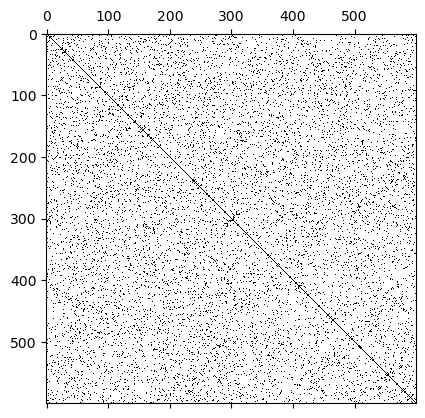

In [2]:
plt.spy(A)
n, m = A.shape
print("Dimensione A", n,m)
#calcolo il numero di elementi diversi da zero
nz = np.count_nonzero(A)
percNonZ = nz / (n*m) * 100
print("percentuale non zero", percNonZ) # matrice grande e sparsa

codA = np.linalg.cond(A)
print("Condizionamento di A", codA)

#A s.d.p lambdai sono reali e > 0; det(Ak) > 0 k = 1,..,n

#Verifica Simmetria
if not np.allclose(A, A.T):
    print("Matrice non è simmetrica")
else:
    print("Matrice Simmetrica")
    autovalori = np.linalg.eigvals(A)
    autovaloriPos = np.all(autovalori > 0)
    print("Matrice definita positiva", autovaloriPos)

#Calcolo diagonale strettamente dominante
# ... lo è

Ax = b A = M-N detM != 0
(M - N)x = b
Mx = Nx + b
x = M^-1 Nx M^-1 b
x^k = M^-1 Nx+ M^-1b

M = D
N = -(E+F)

x^k = D^-1(b-(E+F)x)
x^k = D^-1(b+Nx)

In [3]:
def jacobi(A,b,x0,toll,it_max):          # Definisce una funzione che applica il metodo iterativo di Jacobi
    errore= 1+toll                       

    d= np.diag(A) #to do
    D= np.diag(d) #to do
    n= A.shape[0]                         
    
    E= np.tril(A, -1) #to do
    F= np.triu(A, 1) #to do

    M= D #to do
    N= -(E+F) #to do
    
    T= np.linalg.inv(M)@N #to do

    autovalori=np.linalg.eigvals(T)     # Calcola gli autovalori della matrice di iterazione T
    raggiospettrale= np.max(np.abs(autovalori)) #to do  # Calcola il raggio spettrale

    print("raggio spettrale jacobi", raggiospettrale) # Stampa il raggio spettrale

    it=0                                # Inizializza il contatore delle iterazioni

    er_vet=[]                           # Crea una lista vuota per salvare gli errori a ogni iterazione

    while it <= it_max and errore >= toll: #to do

        x= (b + N@x0) / d.reshape(n, 1) #to do       # Calcola la nuova approssimazione x con la formula di Jacobi

        errore= np.linalg.norm(x - x0) / np.linalg.norm(x) #to do # Calcola l'errore relativo tra due iterazioni successive

        er_vet.append(errore)           # Aggiunge l'errore corrente alla lista degli errori

        x0=x.copy()                     # Aggiorna x0 con la nuova approssimazione x

        it=it+1                         # Incrementa il numero di iterazioni

    return x,it,er_vet                  # Restituisce la soluzione approssimata, il numero di iterazioni e il vettore degli errori


raggio spettrale jacobi 0.17308978590878765


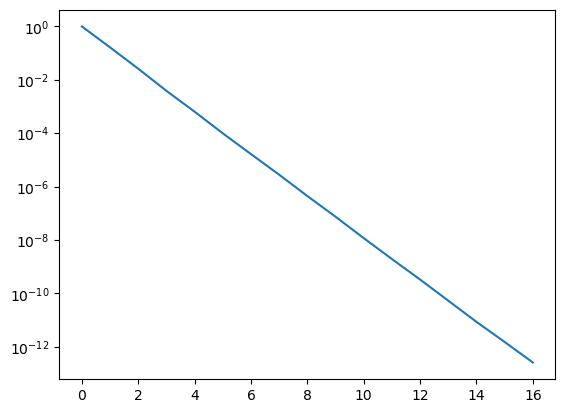

In [4]:
x0 = np.zeros_like(b)
itmax = 1000
toll = 1e-12
x, it, er_vet = jacobi(A,b,x0,toll,itmax)
plt.semilogy(range(it), er_vet)

Dimensione A1 30 30
percentuale non zero 100.0
Condizionamento di A 1.2500000000000018


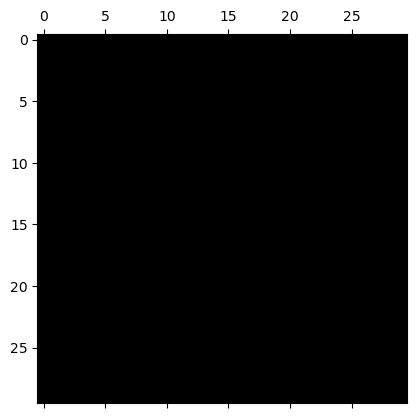

In [14]:
plt.spy(A1)
n1, m1 = A1.shape
print("Dimensione A1", n1,m1)
#calcolo il numero di elementi diversi da zero
nz1 = np.count_nonzero(A1)
percNonZ1 = nz1 / (n1*m1) * 100
print("percentuale non zero", percNonZ1)

codA1 = np.linalg.cond(A1)
print("Condizionamento di A2", codA1)

In [15]:
#Verifica Simmetria
if not np.allclose(A1, A1.T):
    print("Matrice non è simmetrica")
else:
    print("Matrice Simmetrica")
    autovalori = np.linalg.eigvals(A1)
    autovaloriPos = np.all(autovalori > 0)
    print("Matrice definita positiva", autovaloriPos)

Matrice Simmetrica
Matrice definita positiva True


A = L * U
Ax = b
L * Ux = b
{
    Ly = b
    Ux = y
}

In [16]:
L1 = cholesky(A1, lower=True)
LT1 = L1.T
# A = L LT
y1, flag1 = Lsolve(L1, b1)
if flag == 0:
    x1, flag1 = Usolve(LT1, y1)

# print(x1)

Dimensione A2 30 30
percentuale non zero 100.0
Condizionamento di A2 20000.000000005093


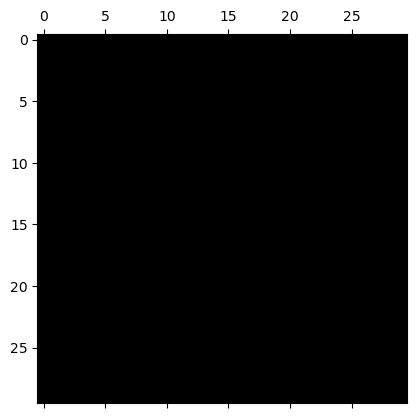

In [18]:
plt.spy(A2)
n2, m2 = A2.shape
print("Dimensione A2", n2,m2)
#calcolo il numero di elementi diversi da zero
nz2 = np.count_nonzero(A2)
percNonZ2 = nz2 / (n2*m2) * 100
print("percentuale non zero", percNonZ2)

codA2 = np.linalg.cond(A2)
print("Condizionamento di A2", codA2)

In [21]:
Q, R = qr(A2)
y2 = Q.T@b2
x2, flag = Usolve(R, y2)
#print(x2)

# Esercizio II

Nell'ingegneria energetica, è essenziale studiare come i pannelli solari rispondono ai cambiamenti delle condizioni ambientali. Si sta conducendo uno studio sull'influenza dell'irradianza solare (I), misurata in $W/m^2$ , sulla potenza elettrica generata (P) da un pannello fotovoltaico in condizioni di laboratorio controllate. L'obiettivo è creare un modello che predica la performance del pannello.

Dati sperimentali

I = np.array([100.0, 200.0, 300.0, 400.0, 500.0, 600.0, 700.0, 800.0, 900.0, 1000.0, 1100.0, 1200.0, 1300.0,1400,1500,1600])

P = np.array([5.2, 10.5, 16.0, 21.8, 27.5, 33.0, 38.2, 43.0, 47.5, 51.5, 55.0, 58.0, 60.5,75.0,90,100])


- implementare le function necessarie per costruire il polinomio interpolatore di Lagrange **[punti 3]**
- implementare le function necessarie per costruire il polinomio approssimante QR-LS  **[punti 3]**
- costruire il polinomio interpolatore di Lagrange che interpola le coppie ($I_i,P_i$), i=0,...,15  e valutarlo in 200 punti appartenenti all'intervallo che contiene i dati sperimentali dell'irradianza e visualizzarlo in un grafico insieme ai dati sperimentali **[punti 1]**
- Stimare la potenza elettrica generata P che si ottiene in corrispondenza a un'irradianza I = $750.0 W/m^2$ e visualizzarne il valore nel grafico precedente. **[punti 1]**
- Definire teoricamente, richiamando il teorema opportuno, da cosa dipende l'errore che si commette quando al posto del polinomio interpolatore si considera la funzione che ha generato i dati. Commentare opportunamente la formula presentata.  **[punti 4]**
- costruire  e visualizzare la retta di regressione a partire dai dati sperimentali ($I_i,P_i$), i=0,...,15 e stampare la norma 2 al quadrato del residuo  **[punti 1]**
- costruire e visualizzare la cubica approssimante i dati nel senso dei minimi quadrati e stampare la norma 2 al quadrato del residuo; **[punti 1]**


Totale **14 punti**

## Domande IA

## Domande Intelligenza Artificiale
**NB: Ogni risposta esatta:  +0.5 punti, ogni risposta errata: -0.5 punti. La mancanza di risposta:  0 punti**

1- **Risolvere un problema mediante Machine Learning significa**:
- Fornire alla macchina i dati affinchè impari da sola a risolvere il problema
- Fornire alla macchina solo dati etichettati affinchè impari da sola a risolvere il problema
- Fornire alla macchina solo dati non etichettati affinchè impari da sola a risolvere il problema
- Fornire alla macchina le esatte istruzioni per risolvere il problema
edizione

   **2**  Quali di queste affermazioni sono vere: 

   (a) Un layer di pooling ha l’effetto di ridurre la dimensionalità del volume di input 

    (b)  In un layer fully-connected tutti i neuroni di output sono collegati a tutti i valori di input 

    (c) In un layer di una rete neurale, il bias è un ulteriore peso apprendibile collegato a un input fittizio con valore sempre 1 

    (d) In una rete Convolutional Neural Network (CNN) i layer di convoluzione sono seguiti da una funzione di attivazione e da un layer fully-connected 

**3.** Quale tra le seguenti affermazioni è FALSA riguardo alla suddivisione del dataset in un contesto di machine learning?

- La suddivisione del dataset in set di training, validation e test è fondamentale per valutare correttamente le prestazioni di un modello di machine learning.
- Il set di training viene utilizzato per addestrare il modello sui dati.
- Il set di validation viene utilizzato per trovare le etichette dei dati di input
- Il set di test viene utilizzato per valutare le prestazioni finali del modello su dati che non sono stati utilizzati per il training o la validation.

**4** Quali di queste affermazioni sono vere:

    Quando si impiega un’architettura di rete esistente: 

    (a)  Dato un problema da risolvere, conviene utilizzare un modello con pesi pre-addestrati su un problema simile 

    (b) I pesi di un modello pre-addestrato non sono modificabili 

    (c) È possibile utilizzare un’architettura esistente anche inizializzandone i pesi con valori casuali 

    (d) Architetture di rete differenti possono raggiungere punteggi di accuratezza simili se addestrate sullo stesso dataset 

    (e) Architetture di rete differenti possono raggiungere punteggi di accuratezza differenti se addestrate sullo stesso dataset 

**5 Per una rete neurale, l’apprendimento è legato a:**
- 	Minimizzare la funzione obiettivo
- Minimizzare la funzione di attivazione
- 	Massimizzare il valore dei pesi tramite l’algoritmo di back-propagation
- Massimizzare il valore della funzione di training

# Domande aperte

- Descrivi e confronta le seguenti varianti del metodo di discesa del gradiente utilizzate per ottimizzare la loss function durante l'addestramento di una rete neurale per un task di regressione:

    Discesa del Gradiente (Batch Gradient Descent)
  
    Discesa del Gradiente Stocastico (Stochastic Gradient Descent - SGD)
  
    Discesa del Gradiente a Mini-Batch (Mini-Batch Gradient Descent)
  **Punti 1.5**  
- Descrivi e confronta i seguenti metodi di apprendimento con learing rate adattivo (adaptive learning rate methods) per l'ottimizzazione dei pesi  durante l'addestramento di reti neurali:

    Adagrad
    RMSProp
    Adam

    Per ciascun metodo, illustra la formula di aggiornamento dei pesi e discuti le sue caratteristiche principali, inclusi vantaggi, svantaggi.**[punti 3.0]**